# Predictive Analysis – Machine Learning

Compare Logistic Regression, SVM, Decision Tree and KNN.

,Model,Accuracy,F1
2,Decision Tree,0.888889,0.916667
0,Logistic Regression,0.777778,0.857143
1,SVM,0.777778,0.857143
3,KNN,0.777778,0.857143


Best model by F1: Decision Tree


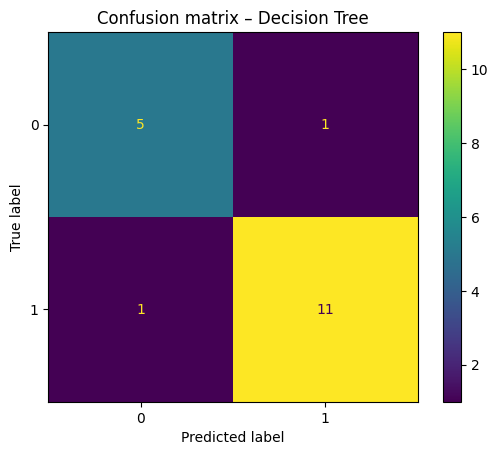

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import requests
from io import StringIO

url = "https://raw.githubusercontent.com/asifikbalpro/Applied-Data-Science-Capstone/main/dataset_part_2.csv"
df = pd.read_csv(StringIO(requests.get(url).text))
X = df[["FlightNumber","PayloadMass","Flights","GridFins","Reused","Legs","Block","ReusedCount"]].astype(float)
X = pd.concat([X, pd.get_dummies(df[["Orbit","LaunchSite"]], drop_first=True)], axis=1)
y = df["Class"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []
predictions = {}
for name, model in models.items():
    if name in ["Logistic Regression","SVM","KNN"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    predictions[name] = pred
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df)

best_name = results_df.iloc[0]["Model"]
print("Best model by F1:", best_name)
cm = confusion_matrix(y_test, predictions[best_name])
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion matrix – " + best_name)
plt.show()


### Conclusion
Use the actual metrics generated by the executed notebook in the final presentation. Report accuracy, F1 and the confusion matrix together.